# House Price Analysis

## Business Problem
The goal of this project is to identify the factors that influence housing prices and develop predictive models capable of estimating property values.

This analysis includes:
- Data cleaning
- Exploratory data analysis
- Feature engineering
- Machine learning modeling
- Model comparison
- Business insights

## Results Summary

Dataset Size: 545 houses

Best Model:
- Tuned Ridge Regression (Refined Features)

Performance:
- R² = 0.6673
- MAE = $893,370

Key Drivers:
- Area
- Bathrooms
- Main Road Access
- Parking
- Preferred Area

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import xgboost as xgb
from google.colab import files

In [40]:
# Assuming 'Housing.csv' has already been uploaded or is available in the environment.
# If not, please upload it using files.upload() before running this cell.
uploaded = files.upload()
df = pd.read_csv('Housing.csv')
display(df.head())

Saving Housing_Dataset.csv to Housing_Dataset.csv


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [41]:
print('--- DataFrame Info ---')
df.info()
print('\n--- DataFrame Description ---')
display(df.describe())
print('\n--- DataFrame Shape ---')
print(df.shape)

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

--- DataFrame Description ---


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



--- DataFrame Shape ---
(545, 13)


## Data Cleaning
The dataset was inspected for:
- Missing values
- Duplicate records
- Incorrect data types
- Categorical variable encoding

In [42]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [43]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


In [44]:
# List of binary columns to map ('yes'/'no' to 1/0)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Mapping function
def map_binary(x):
    return x.map({'yes': 1, 'no': 0})

# Apply the mapping to the selected columns
df[binary_cols] = df[binary_cols].apply(map_binary)

print('DataFrame after encoding binary variables:')
display(df.head())

DataFrame after encoding binary variables:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [45]:
# Perform one-hot encoding for 'furnishingstatus' column
# drop_first=True avoids multicollinearity by dropping the first category
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print('DataFrame after one-hot encoding "furnishingstatus":')
display(df.head())

DataFrame after one-hot encoding "furnishingstatus":


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


# Exploratory Data Analysis

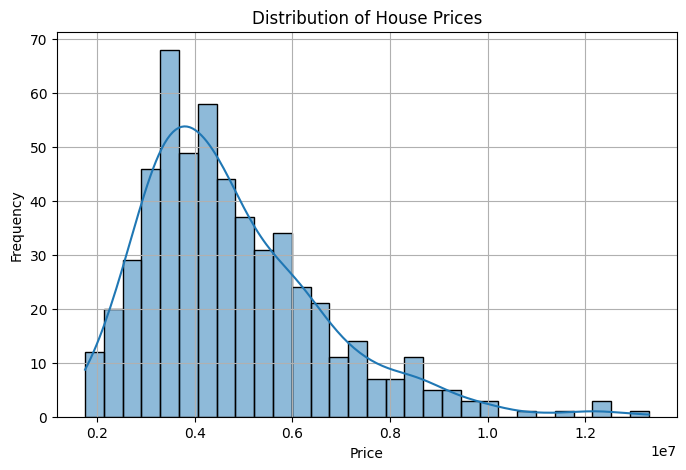

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

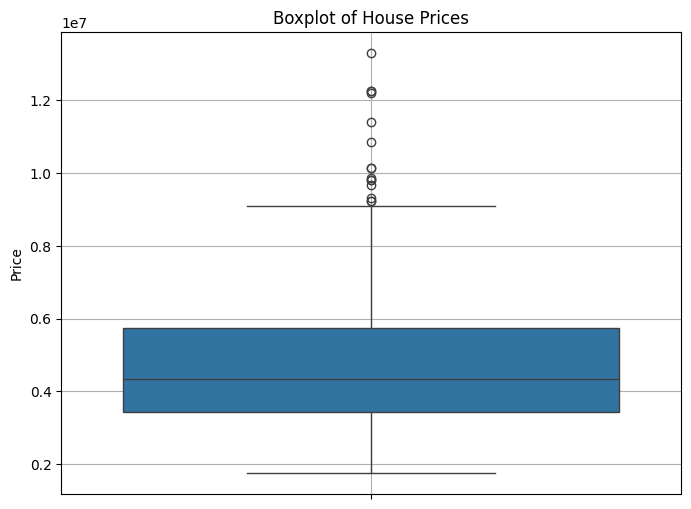

In [47]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['price'])
plt.title('Boxplot of House Prices')
plt.ylabel('Price')
plt.grid(True)
plt.show()

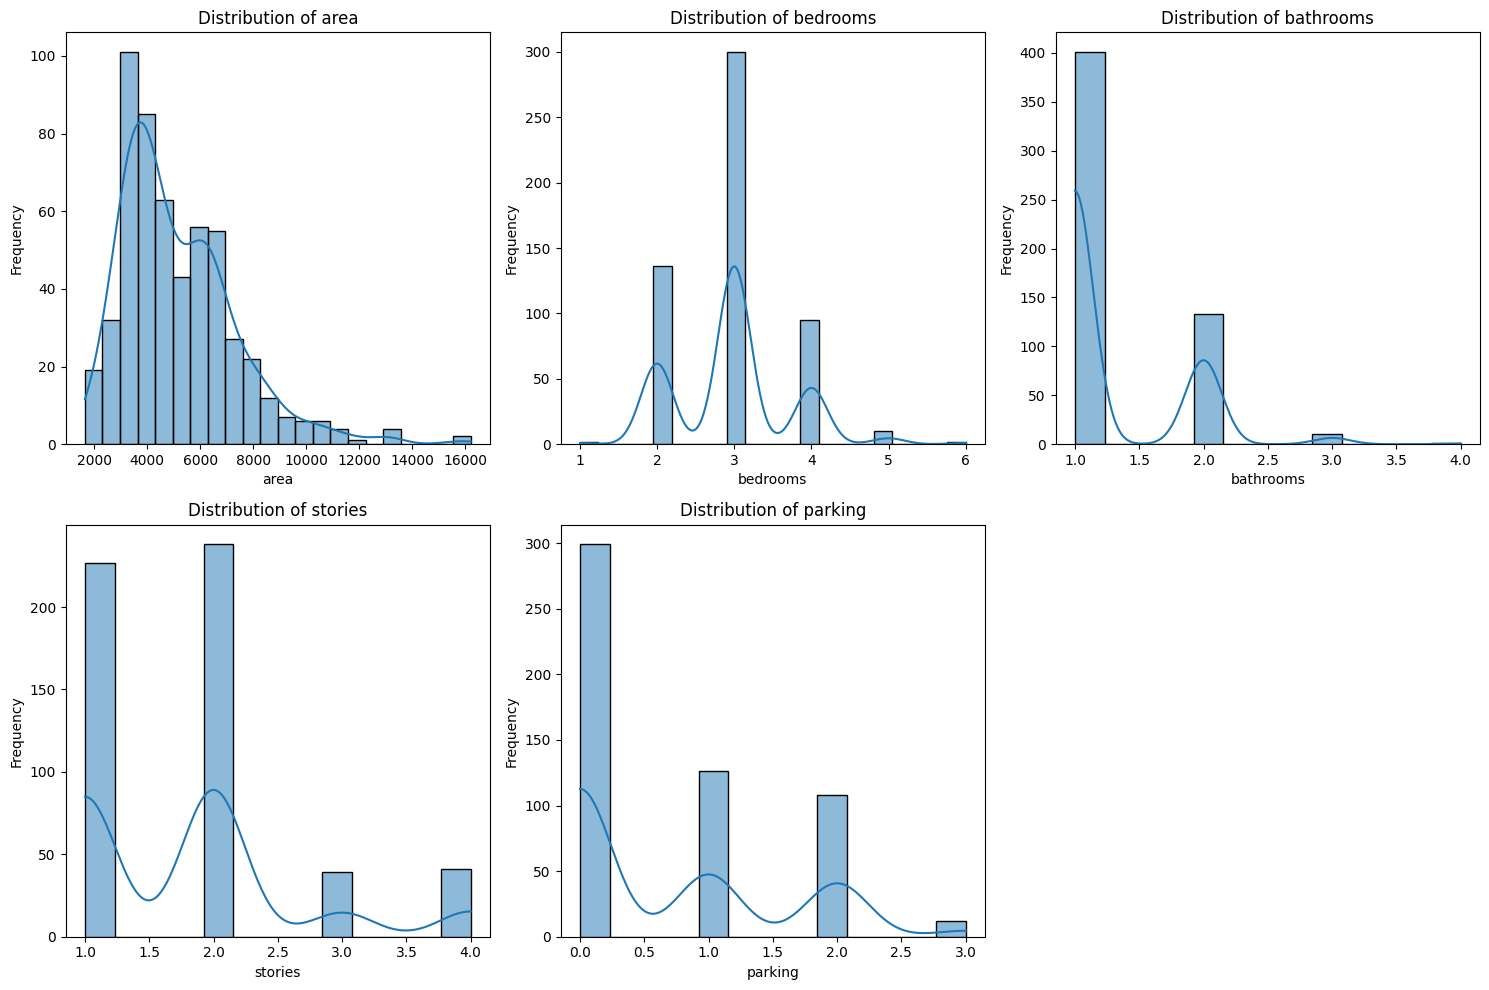

In [48]:
numerical_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

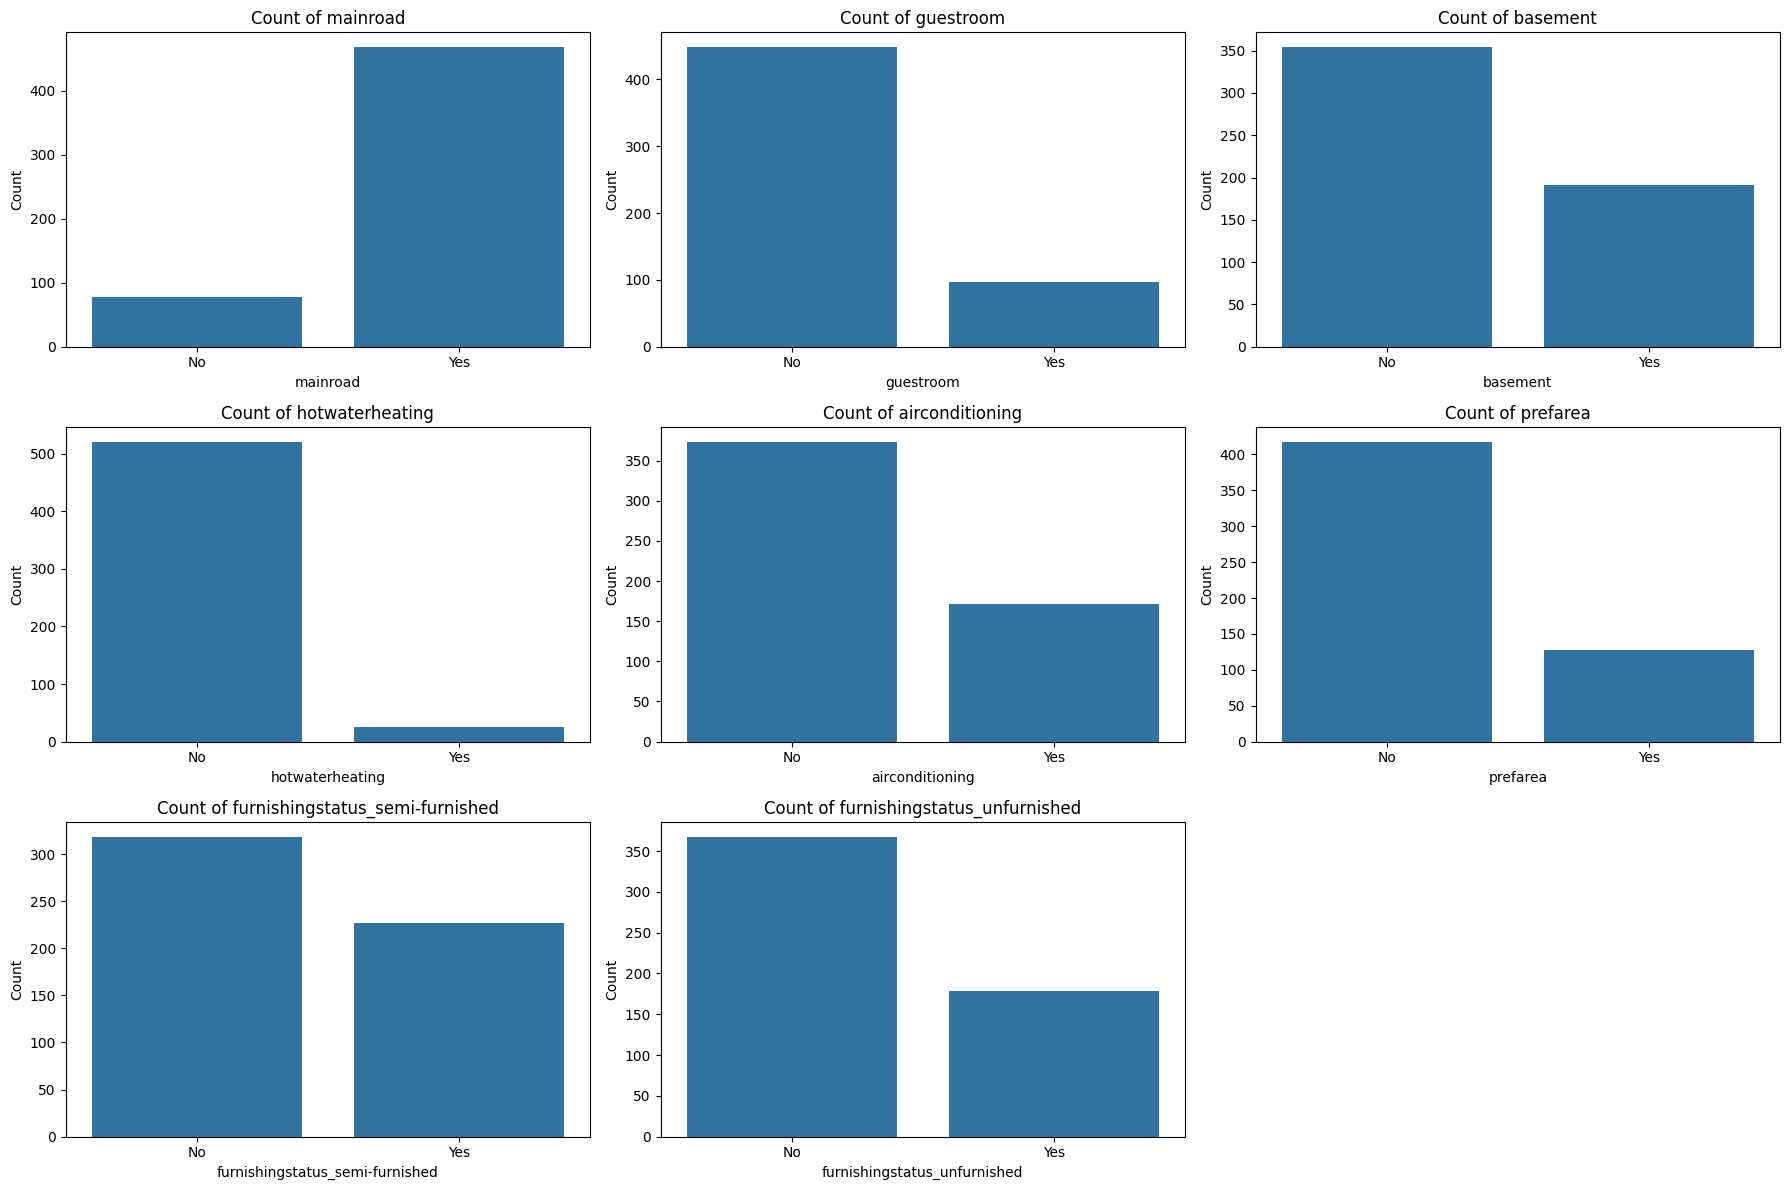

In [49]:
categorical_features = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea',
    'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'
]

plt.figure(figsize=(18, 12))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=df[feature])
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks([0, 1], ['No', 'Yes']) # Assuming 0/1 encoding for these columns
plt.tight_layout()
plt.show()

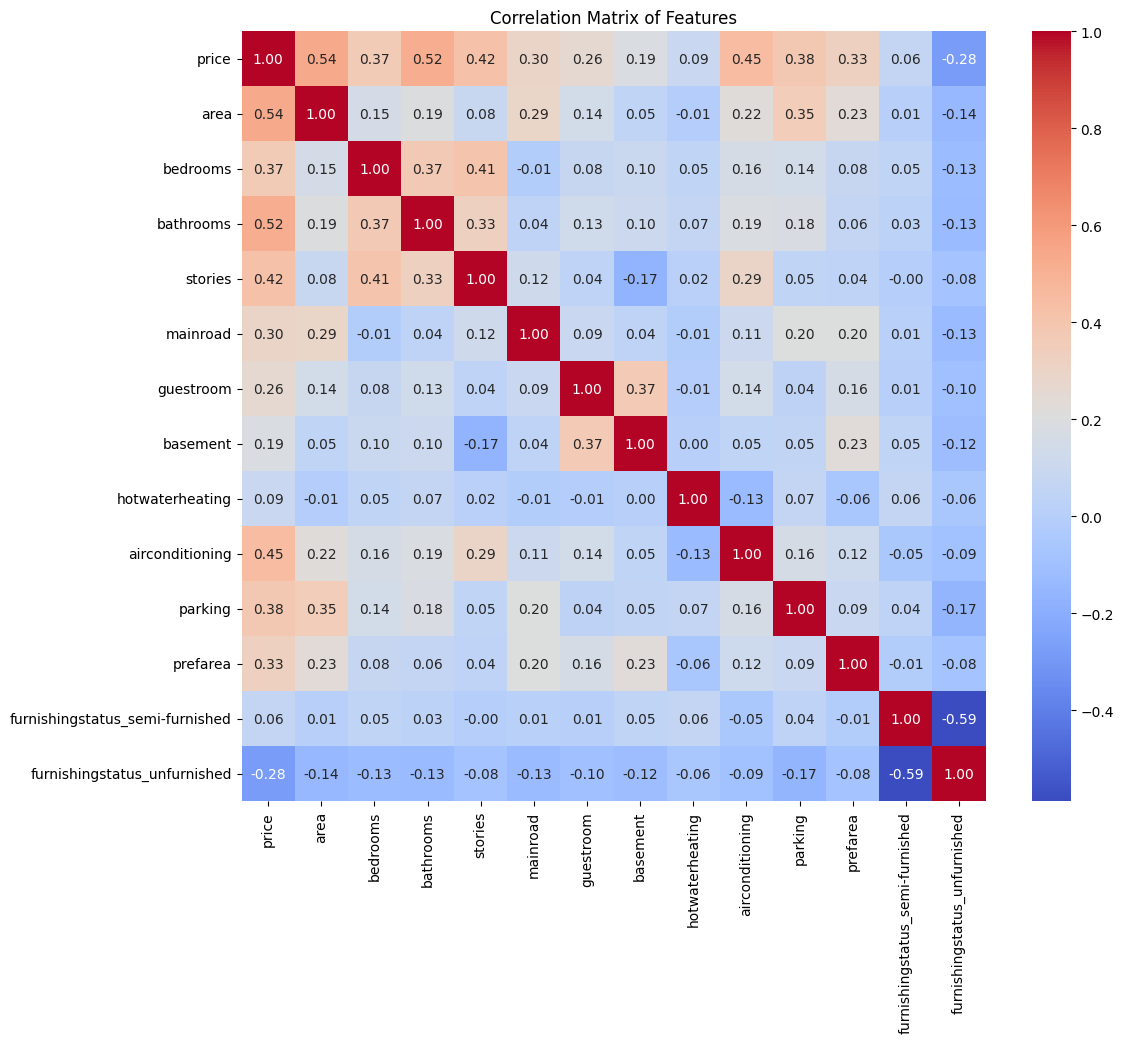

In [50]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

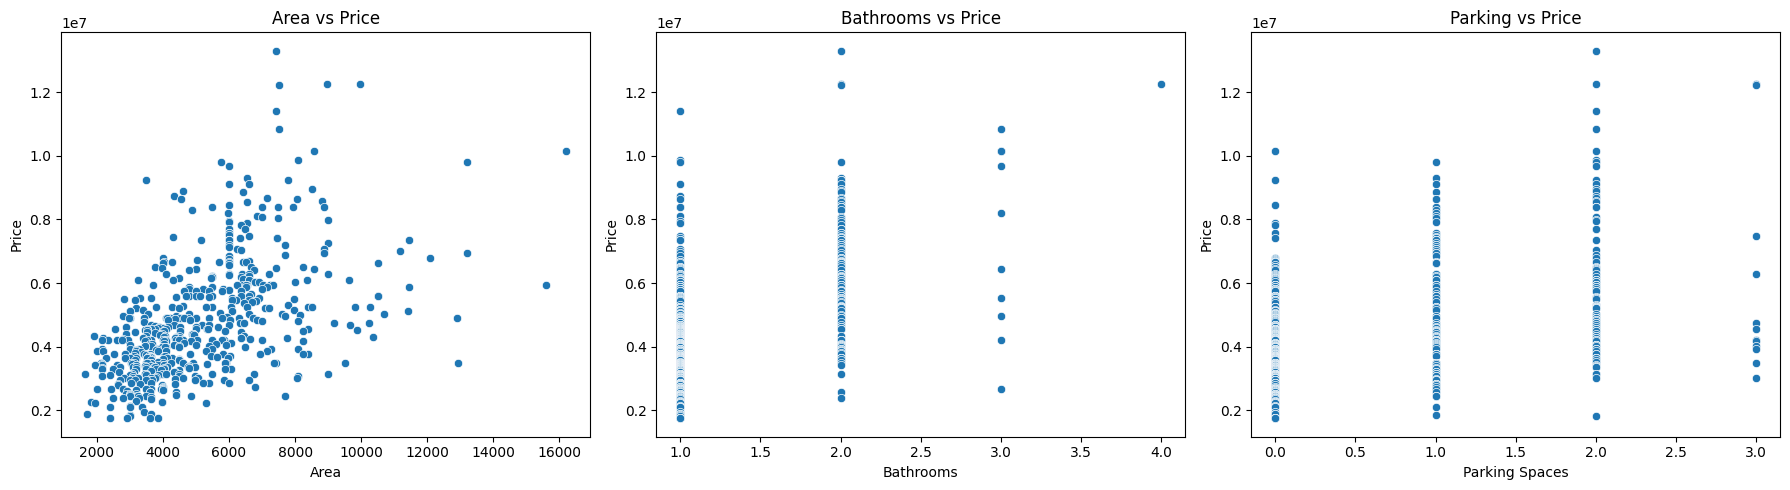

In [51]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='area', y='price', data=df)
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')

plt.subplot(1, 3, 2)
sns.scatterplot(x='bathrooms', y='price', data=df)
plt.title('Bathrooms vs Price')
plt.xlabel('Bathrooms')
plt.ylabel('Price')

plt.subplot(1, 3, 3)
sns.scatterplot(x='parking', y='price', data=df)
plt.title('Parking vs Price')
plt.xlabel('Parking Spaces')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [52]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'price'
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1 # Interquartile Range

# Define outlier bounds using the 1.5 * IQR rule
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Identify outliers in the 'price' column
outliers_price = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print(f"Number of outliers in 'price' column: {len(outliers_price)}")
print("Outliers in 'price' column (first 5 rows if any):")
display(outliers_price.head())

Number of outliers in 'price' column: 15
Outliers in 'price' column (first 5 rows if any):


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


# Feature Engineering

In [53]:
# Apply a logarithmic transformation to the 'area' column
# Adding 1 to the area to handle cases where area might be 0, though not expected here.
df['area_log'] = np.log1p(df['area'])

# Drop the original 'area' column to avoid multicollinearity and use the transformed feature
df_transformed = df.drop('area', axis=1)

print("DataFrame with 'area_log' and without original 'area' column (first 5 rows):")
display(df_transformed.head())

DataFrame with 'area_log' and without original 'area' column (first 5 rows):


,price,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_log
0,13300000,4,2,3,1,0,0,0,1,2,1,False,False,8.912069
1,12250000,4,4,4,1,0,0,0,1,3,0,False,False,9.100637
2,12250000,3,2,2,1,0,1,0,0,2,1,True,False,9.206433
3,12215000,4,2,2,1,0,1,0,1,3,1,False,False,8.922792
4,11410000,4,1,2,1,1,1,0,1,2,0,False,False,8.912069


In [54]:
# Separate features (X_new) and target (y)
X_new = df_transformed.drop('price', axis=1)
y = df_transformed['price']

# Split the data into training and testing sets (70% train, 30% test)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.3, random_state=42)

print(f"X_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")

X_train_new shape: (381, 13)
X_test_new shape: (164, 13)
y_train_new shape: (381,)
y_test_new shape: (164,)


In [55]:
# Initialize the MinMaxScaler
scaler_new = MinMaxScaler()

# Identify numerical columns (excluding boolean, which are already 0/1)
numerical_cols_new = X_train_new.select_dtypes(include=['int64', 'float64']).columns

# Apply scaling to the numerical columns of the training and testing sets
X_train_new[numerical_cols_new] = scaler_new.fit_transform(X_train_new[numerical_cols_new])
X_test_new[numerical_cols_new] = scaler_new.transform(X_test_new[numerical_cols_new])

print("Scaled X_train_new head:")
display(X_train_new.head())
print("\nScaled X_test_new head:")
display(X_test_new.head())

Scaled X_train_new head:


,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_log
126,0.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.666667,1.0,False,True,0.642498
363,0.2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.0,True,False,0.339528
370,0.2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.666667,0.0,True,False,0.417222
31,0.4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.666667,0.0,True,False,0.632604
113,0.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.666667,1.0,False,False,0.771806



Scaled X_test_new head:


,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area_log
316,0.6,0.333333,0.333333,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,False,True,0.557755
77,0.4,0.333333,0.666667,1.0,0.0,0.0,0.0,1.0,0.000000,1.0,False,False,0.600158
360,0.2,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,True,False,0.391958
90,0.4,0.000000,0.333333,1.0,0.0,0.0,0.0,1.0,0.000000,0.0,True,False,0.485292
493,0.4,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,False,False,0.383202


In [56]:
# Initialize PolynomialFeatures with degree 2 (to capture interactions and squared terms)
poly_new = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform the training data to create polynomial features
X_train_poly_new = poly_new.fit_transform(X_train_new)
# Transform the test data using the fitted polynomial features
X_test_poly_new = poly_new.transform(X_test_new)

# Get feature names for the new polynomial features for better interpretability
poly_feature_names_new = poly_new.get_feature_names_out(X_train_new.columns)

# Convert back to DataFrame for easier inspection and model input
X_train_poly_df_new = pd.DataFrame(X_train_poly_new, columns=poly_feature_names_new, index=X_train_new.index)
X_test_poly_df_new = pd.DataFrame(X_test_poly_new, columns=poly_feature_names_new, index=X_test_new.index)

print(f"Original X_train_new shape: {X_train_new.shape}")
print(f"New X_train_poly_df_new shape: {X_train_poly_df_new.shape}")
print("First 5 polynomial features (new):")
print(poly_feature_names_new[:5])
print("\nScaled X_train_poly_df_new head:")
display(X_train_poly_df_new.head())

Original X_train_new shape: (381, 13)
New X_train_poly_df_new shape: (381, 104)
First 5 polynomial features (new):
['bedrooms' 'bathrooms' 'stories' 'mainroad' 'guestroom']

Scaled X_train_poly_df_new head:


,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,...,prefarea^2,prefarea furnishingstatus_semi-furnished,prefarea furnishingstatus_unfurnished,prefarea area_log,furnishingstatus_semi-furnished^2,furnishingstatus_semi-furnished furnishingstatus_unfurnished,furnishingstatus_semi-furnished area_log,furnishingstatus_unfurnished^2,furnishingstatus_unfurnished area_log,area_log^2
126,0.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.666667,1.0,...,1.0,0.0,1.0,0.642498,0.0,0.0,0.000000,1.0,0.642498,0.412804
363,0.2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,1.0,0.0,0.339528,0.0,0.000000,0.115279
370,0.2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.666667,0.0,...,0.0,0.0,0.0,0.000000,1.0,0.0,0.417222,0.0,0.000000,0.174074
31,0.4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.666667,0.0,...,0.0,0.0,0.0,0.000000,1.0,0.0,0.632604,0.0,0.000000,0.400187
113,0.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.666667,1.0,...,1.0,0.0,0.0,0.771806,0.0,0.0,0.000000,0.0,0.000000,0.595685


# Ridge Regression

In [57]:
# Define a range of alpha values (regularization strengths) to test
alphas_new = np.logspace(-3, 2, 100) # From 0.001 to 100

# Initialize RidgeCV with cross-validation to find the best alpha
# RidgeCV performs leave-one-out cross-validation by default for alpha selection
ridge_cv_model_new = RidgeCV(alphas=alphas_new, store_cv_values=True)

# Fit the model to the training data (with polynomial features)
ridge_cv_model_new.fit(X_train_poly_df_new, y_train_new)

# Get the best alpha found by cross-validation
best_alpha_new = ridge_cv_model_new.alpha_
print(f"Best alpha found by RidgeCV (with log-transformed area): {best_alpha_new:.4f}")

Best alpha found by RidgeCV (with log-transformed area): 5.4623


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


In [58]:
# Make predictions on the test set using the tuned Ridge model
y_pred_ridge_tuned_new = ridge_cv_model_new.predict(X_test_poly_df_new)

# Evaluate the tuned Ridge model's performance
r2_ridge_tuned_new = r2_score(y_test_new, y_pred_ridge_tuned_new)
mae_ridge_tuned_new = mean_absolute_error(y_test_new, y_pred_ridge_tuned_new)
mse_ridge_tuned_new = mean_squared_error(y_test_new, y_pred_ridge_tuned_new)
rmse_ridge_tuned_new = np.sqrt(mse_ridge_tuned_new)

print(f"\nPerformance with Tuned Ridge Regression (alpha={best_alpha_new:.4f}):")
print(f"R-squared (R²): {r2_ridge_tuned_new:.4f}")
print(f"Mean Absolute Error (MAE): {mae_ridge_tuned_new:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge_tuned_new:.2f}")


Performance with Tuned Ridge Regression (alpha=5.4623):
R-squared (R²): 0.6637
Mean Absolute Error (MAE): 892181.76
Root Mean Squared Error (RMSE): 1203384.98


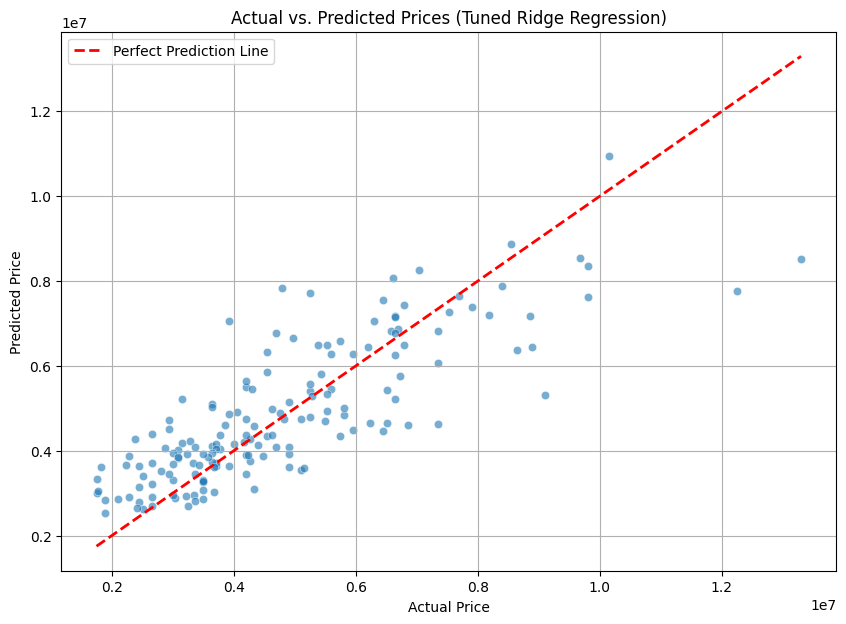

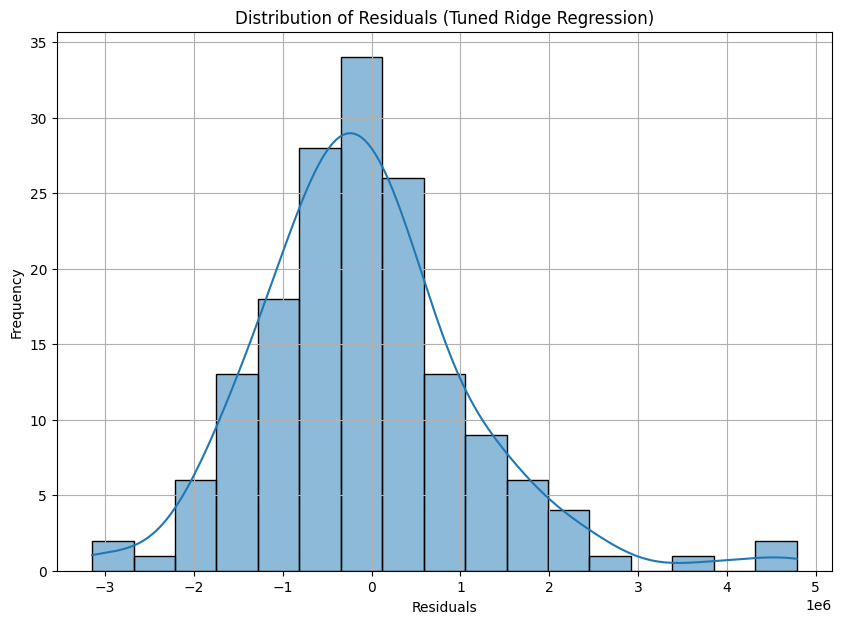

In [59]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_new, y=y_pred_ridge_tuned_new, alpha=0.6)
plt.plot([y_test_new.min(), y_test_new.max()], [y_test_new.min(), y_test_new.max()], 'r--', lw=2, label='Perfect Prediction Line') # 45-degree line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices (Tuned Ridge Regression)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate residuals
residuals_ridge = y_test_new - y_pred_ridge_tuned_new

plt.figure(figsize=(10, 7))
sns.histplot(residuals_ridge, kde=True)
plt.title('Distribution of Residuals (Tuned Ridge Regression)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Random Forest

In [60]:
# Initialize the Random Forest Regressor with a fixed random state for reproducibility
rf_model = RandomForestRegressor(random_state=42)

# Fit the model to the training data (with polynomial features)
rf_model.fit(X_train_poly_df_new, y_train_new)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_poly_df_new)

print('Random Forest model trained and predictions made.')

Random Forest model trained and predictions made.


In [61]:
# Evaluate the Random Forest model's performance
r2_rf = r2_score(y_test_new, y_pred_rf)
mae_rf = mean_absolute_error(y_test_new, y_pred_rf)
mse_rf = mean_squared_error(y_test_new, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("\nPerformance with Random Forest Regressor (Default Parameters):")
print(f"R-squared (R²): {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")


Performance with Random Forest Regressor (Default Parameters):
R-squared (R²): 0.6176
Mean Absolute Error (MAE): 930305.13
Root Mean Squared Error (RMSE): 1283295.45


In [62]:
# Define the parameter distribution to sample from for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False] # Whether bootstrap samples are used when building trees
}

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                      param_distributions=param_dist,
                                      n_iter=50, # Number of parameter settings that are sampled
                                      cv=5, # Number of folds for cross-validation
                                      verbose=2,
                                      random_state=42,
                                      n_jobs=-1, # Use all available cores
                                      scoring='r2') # Use R-squared as the scoring metric

# Fit the random search model to the training data
random_search_rf.fit(X_train_poly_df_new, y_train_new)

print('\nRandomizedSearchCV for Random Forest completed.')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV for Random Forest completed.


In [63]:
print(f"Best hyperparameters found for Random Forest: {random_search_rf.best_params_}")

# Get the best estimator (model) from the random search
best_rf_model = random_search_rf.best_estimator_

# Make predictions on the test set using the best Random Forest model
y_pred_best_rf = best_rf_model.predict(X_test_poly_df_new)

# Evaluate the best Random Forest model's performance
r2_best_rf = r2_score(y_test_new, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test_new, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test_new, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)

print("\nPerformance with Tuned Random Forest Regressor:")
print(f"R-squared (R²): {r2_best_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_best_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_rf:.2f}")

Best hyperparameters found for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}

Performance with Tuned Random Forest Regressor:
R-squared (R²): 0.6383
Mean Absolute Error (MAE): 916640.72
Root Mean Squared Error (RMSE): 1247992.81


Top 10 Feature Importances from Tuned Random Forest:


,Feature,Importance
58,mainroad area_log,0.068988
12,area_log,0.066367
103,area_log^2,0.062313
37,bathrooms area_log,0.058884
25,bedrooms area_log,0.056171
48,stories area_log,0.047023
88,airconditioning area_log,0.038775
93,parking area_log,0.029992
14,bedrooms bathrooms,0.028103
28,bathrooms mainroad,0.026391


/tmp/ipykernel_4650/2884664353.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


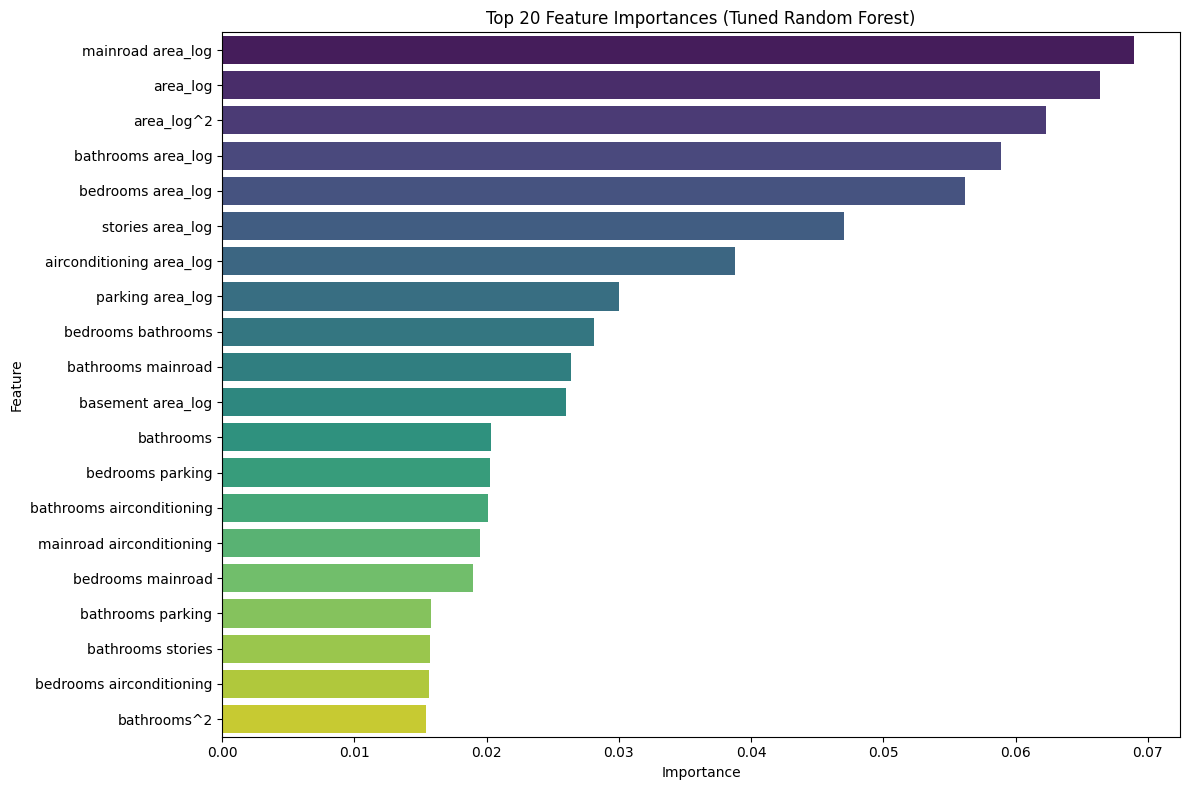

In [64]:
# Get feature importances from the best Random Forest model
feature_importances = best_rf_model.feature_importances_

# Get the names of the features used for training
feature_names = X_train_poly_df_new.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from Tuned Random Forest:")
display(importance_df.head(10))

# Plot the top 20 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# XGBoost

In [65]:
# Initialize the XGBoost Regressor with a fixed random state
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Fit the model to the training data (with polynomial features)
xgb_model.fit(X_train_poly_df_new, y_train_new)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_poly_df_new)

print('XGBoost model trained and predictions made.')

XGBoost model trained and predictions made.


In [66]:
# Evaluate the XGBoost model's performance
r2_xgb = r2_score(y_test_new, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_new, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_new, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("\nPerformance with XGBoost Regressor (Default Parameters):")
print(f"R-squared (R²): {r2_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")


Performance with XGBoost Regressor (Default Parameters):
R-squared (R²): 0.4773
Mean Absolute Error (MAE): 1038742.44
Root Mean Squared Error (RMSE): 1500374.57


In [67]:
# Define the parameter distribution to sample from for RandomizedSearchCV for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500, 700, 1000], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10], # Maximum depth of a tree
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2, 0.3, 0.4], # Minimum loss reduction required to make a further partition on a leaf node
    'min_child_weight': [1, 3, 5, 7], # Minimum sum of instance weight (hessian) needed in a child
}

# Initialize RandomizedSearchCV for XGBoost
random_search_xgb = RandomizedSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                                       param_distributions=param_dist_xgb,
                                       n_iter=50, # Number of parameter settings that are sampled
                                       cv=5, # Number of folds for cross-validation
                                       verbose=2,
                                       random_state=42,
                                       n_jobs=-1, # Use all available cores
                                       scoring='r2') # Use R-squared as the scoring metric

# Fit the random search model for XGBoost to the training data
random_search_xgb.fit(X_train_poly_df_new, y_train_new)

print('\nRandomizedSearchCV for XGBoost completed.')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV for XGBoost completed.


In [68]:
print(f"Best hyperparameters found for XGBoost: {random_search_xgb.best_params_}")

# Get the best estimator (model) from the random search
best_xgb_model = random_search_xgb.best_estimator_

# Make predictions on the test set using the best XGBoost model
y_pred_best_xgb = best_xgb_model.predict(X_test_poly_df_new)

# Evaluate the best XGBoost model's performance
r2_best_xgb = r2_score(y_test_new, y_pred_best_xgb)
mae_best_xgb = mean_absolute_error(y_test_new, y_pred_best_xgb)
mse_best_xgb = mean_squared_error(y_test_new, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)

print("\nPerformance with Tuned XGBoost Regressor:")
print(f"R-squared (R²): {r2_best_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_best_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_xgb:.2f}")

Best hyperparameters found for XGBoost: {'subsample': 0.6, 'n_estimators': 700, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.4, 'colsample_bytree': 0.9}

Performance with Tuned XGBoost Regressor:
R-squared (R²): 0.6513
Mean Absolute Error (MAE): 924189.38
Root Mean Squared Error (RMSE): 1225366.14


In [69]:
results = pd.DataFrame({
    'Model': [
        'Tuned Ridge Regression',
        'Tuned Random Forest',
        'Tuned XGBoost'
    ],
    'R-squared': [
        r2_ridge_tuned_new,
        r2_best_rf,
        r2_best_xgb
    ],
    'MAE': [
        mae_ridge_tuned_new,
        mae_best_rf,
        mae_best_xgb
    ],
    'RMSE': [
        rmse_ridge_tuned_new,
        rmse_best_rf,
        rmse_best_xgb
    ]
})

print("\nModel Performance Comparison:")
display(results.round(4).sort_values(by='R-squared', ascending=False))

# Get the best performing model based on R-squared
best_model_overall = results.loc[results['R-squared'].idxmax()]
print("\nOverall Best Performing Model:")
display(best_model_overall.round(4))


Model Performance Comparison:


,Model,R-squared,MAE,RMSE
0,Tuned Ridge Regression,0.6637,892181.7572,1.203385e+06
2,Tuned XGBoost,0.6513,924189.3750,1.225366e+06
1,Tuned Random Forest,0.6383,916640.7155,1.247993e+06



Overall Best Performing Model:


,0
Model,Tuned Ridge Regression
R-squared,0.663724
MAE,892181.757154
RMSE,1203384.982082


/tmp/ipykernel_4650/443093523.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-squared', y='Model', data=results_sorted, palette='viridis')


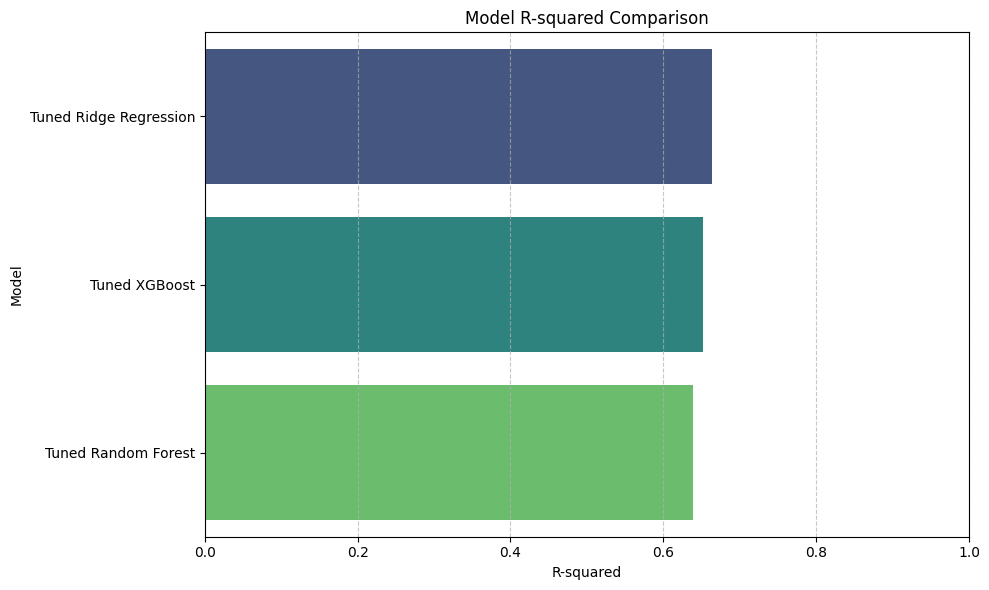

In [70]:
# Sort the results by R-squared for better visualization
results_sorted = results.sort_values(by='R-squared', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='R-squared', y='Model', data=results_sorted, palette='viridis')
plt.title('Model R-squared Comparison')
plt.xlabel('R-squared')
plt.ylabel('Model')
plt.xlim(0, 1) # R-squared typically ranges from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Business Insights

## Key Findings
1. Area was the strongest driver of price.
2. Preferred areas increased value.
3. Bathrooms were more important than bedrooms.
4. Parking positively affected pricing.
5. Furnishing status influenced value.

# Recommendations

- Prioritize square footage in valuations.
- Consider neighborhood desirability.
- Include parking and bathrooms in pricing models.
- Highlight premium amenities in listings.

In [71]:
# First, re-run feature engineering for refined models, if not already done, and define X_train_refined, X_test_refined

# Calculate residuals for the new model
residuals_new = y_test_new - y_pred_ridge_tuned_new

error_analysis_df = pd.DataFrame({
    'Actual_Price': y_test_new,
    'Predicted_Price': y_pred_ridge_tuned_new,
    'Absolute_Error': np.abs(residuals_new)
})

largest_errors = error_analysis_df.sort_values(by='Absolute_Error', ascending=False)

# Create X_test_combined as it's used in subsequent steps
X_test_combined = X_test_new.copy()
X_test_combined['Actual_Price'] = y_test_new
X_test_combined['Predicted_Price'] = y_pred_ridge_tuned_new
X_test_combined['Absolute_Error'] = np.abs(y_test_new - y_pred_ridge_tuned_new)

# Get the indices of the top 5 largest errors
top_5_error_indices = largest_errors.head(5).index

# Create a boolean column to distinguish high-error houses
X_test_combined['is_high_error'] = X_test_combined.index.isin(top_5_error_indices)

# Get the top 25 most influential feature names from coef_df (from previous Ridge analysis)
# Need to regenerate coef_df
coefficients = ridge_cv_model_new.coef_
feature_names = poly_new.get_feature_names_out(X_train_new.columns)
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Absolute_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)
top_features_to_select = coef_df['Feature'].head(25).tolist()

# Identify original (base) numerical and boolean features
original_numeric_cols = X_train_new.select_dtypes(include=['int64', 'float64']).columns.tolist()
original_bool_cols = X_train_new.select_dtypes(include=['bool']).columns.tolist()
base_features = original_numeric_cols + original_bool_cols

# Create a function to generate selected features (base + interactions) from the original X_train/X_test_new
def create_refined_features(df_original, selected_features_list):
    df_refined = pd.DataFrame(index=df_original.index)

    # Add base features directly
    for feature in base_features:
        if feature in df_original.columns:
            df_refined[feature] = df_original[feature]

    # Add interaction and squared terms based on the selected_features_list
    for feature_name in selected_features_list:
        if feature_name not in df_refined.columns: # Avoid duplicating base features
            # Handle squared terms (e.g., 'area_log^2')
            if '^2' in feature_name:
                base_feat = feature_name.replace('^2', '')
                if base_feat in df_original.columns:
                    df_refined[feature_name] = df_original[base_feat] ** 2
            # Handle interaction terms (e.g., 'bathrooms mainroad')
            elif ' ' in feature_name: # Simple check for interaction (space between names)
                f1, f2 = feature_name.split(' ')
                if f1 in df_original.columns and f2 in df_original.columns:
                    df_refined[feature_name] = df_original[f1] * df_original[f2]
            # Handle any other special polynomial features if present

    # Ensure boolean columns are converted to 0/1 for arithmetic operations
    for col in df_refined.select_dtypes(include=['bool']).columns:
        df_refined[col] = df_refined[col].astype(int)

    df_refined = df_refined.dropna(axis=1)

    return df_refined

X_train_refined = create_refined_features(X_train_new, top_features_to_select)
X_test_refined = create_refined_features(X_test_new, top_features_to_select)

# Now, create new interaction features based on outlier analysis
X_train_refined['area_log_x_prefarea'] = X_train_refined['area_log'] * X_train_refined['prefarea']
X_test_refined['area_log_x_prefarea'] = X_test_refined['area_log'] * X_test_refined['prefarea']

X_train_refined['area_log_x_airconditioning'] = X_train_refined['area_log'] * X_train_refined['airconditioning']
X_test_refined['area_log_x_airconditioning'] = X_test_refined['area_log'] * X_test_refined['airconditioning']

# Re-scale the refined features
scaler_refined = MinMaxScaler()
numerical_cols_refined = X_train_refined.select_dtypes(include=['int64', 'float64']).columns
X_train_refined[numerical_cols_refined] = scaler_refined.fit_transform(X_train_refined[numerical_cols_refined])
X_test_refined[numerical_cols_refined] = scaler_refined.transform(X_test_refined[numerical_cols_refined])

# Train the refined Ridge model
ridge_refined_model = Ridge(alpha=best_alpha_new)
ridge_refined_model.fit(X_train_refined, y_train_new)
y_pred_ridge_refined = ridge_refined_model.predict(X_test_refined)

r2_ridge_refined = r2_score(y_test_new, y_pred_ridge_refined)
mae_ridge_refined = mean_absolute_error(y_test_new, y_pred_ridge_refined)
rmse_ridge_refined = np.sqrt(mean_squared_error(y_test_new, y_pred_ridge_refined))

# Train the refined XGBoost model (for ensemble)
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'min_child_weight': [1, 3, 5, 7],
}
random_search_xgb_refined = RandomizedSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                                       param_distributions=param_dist_xgb,
                                       n_iter=50,
                                       cv=5,
                                       verbose=0,
                                       random_state=42,
                                       n_jobs=-1,
                                       scoring='r2')
random_search_xgb_refined.fit(X_train_refined, y_train_new)
best_xgb_model_refined = random_search_xgb_refined.best_estimator_

r2_best_xgb_refined = r2_score(y_test_new, best_xgb_model_refined.predict(X_test_refined))
mae_best_xgb_refined = mean_absolute_error(y_test_new, best_xgb_model_refined.predict(X_test_refined))
rmse_best_xgb_refined = np.sqrt(mean_squared_error(y_test_new, best_xgb_model_refined.predict(X_test_refined)))

# Train and evaluate refined Random Forest model (for ensemble)
random_search_rf_refined = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                              param_distributions=param_dist,
                                              n_iter=50,
                                              cv=5,
                                              verbose=0,
                                              random_state=42,
                                              n_jobs=-1,
                                              scoring='r2')
random_search_rf_refined.fit(X_train_refined, y_train_new)
best_rf_model_refined = random_search_rf_refined.best_estimator_

r2_best_rf_refined = r2_score(y_test_new, best_rf_model_refined.predict(X_test_refined))
mae_best_rf_refined = mean_absolute_error(y_test_new, best_rf_model_refined.predict(X_test_refined))
rmse_best_rf_refined = np.sqrt(mean_squared_error(y_test_new, best_rf_model_refined.predict(X_test_refined)))



# Define base estimators for stacking
estimators = [
    ('ridge', ridge_refined_model),
    ('xgb', best_xgb_model_refined)
]

# Initialize StackingRegressor
stacking_model = StackingRegressor(estimators=estimators,
                                   final_estimator=Ridge(),
                                   passthrough=True,
                                   cv=5,
                                   n_jobs=-1,
                                   verbose=0)

stacking_model.fit(X_train_refined, y_train_new)
y_pred_stacking = stacking_model.predict(X_test_refined)

r2_stacking = r2_score(y_test_new, y_pred_stacking)
mae_stacking = mean_absolute_error(y_test_new, y_pred_stacking)
rmse_stacking = np.sqrt(mean_squared_error(y_test_new, y_pred_stacking))

print("Ensemble models prepared.")

Ensemble models prepared.


In [72]:
results = pd.DataFrame({
    'Model': [
        'Tuned Ridge (Full Poly)', 'Tuned Ridge (Refined)',
        'Tuned Random Forest (Full Poly)', 'Tuned Random Forest (Refined)',
        'Tuned XGBoost (Full Poly)', 'Tuned XGBoost (Refined)',
        'Stacked Ensemble'
    ],
    'R-squared': [
        r2_ridge_tuned_new, r2_ridge_refined,
        r2_best_rf, r2_best_rf_refined,
        r2_best_xgb, r2_best_xgb_refined,
        r2_stacking
    ],
    'MAE': [
        mae_ridge_tuned_new, mae_ridge_refined,
        mae_best_rf, mae_best_rf_refined,
        mae_best_xgb, mae_best_xgb_refined,
        mae_stacking
    ],
    'RMSE': [
        rmse_ridge_tuned_new, rmse_ridge_refined,
        rmse_best_rf, rmse_best_rf_refined,
        rmse_best_xgb, rmse_best_xgb_refined,
        rmse_stacking
    ]
})

print("\nModel Performance Comparison:")
display(results.round(4).sort_values(by='R-squared', ascending=False))


Model Performance Comparison:


,Model,R-squared,MAE,RMSE
1,Tuned Ridge (Refined),0.6673,893370.7987,1.197051e+06
6,Stacked Ensemble,0.6670,891455.2361,1.197472e+06
0,Tuned Ridge (Full Poly),0.6637,892181.7572,1.203385e+06
4,Tuned XGBoost (Full Poly),0.6513,924189.3750,1.225366e+06
5,Tuned XGBoost (Refined),0.6389,934420.8750,1.247095e+06
2,Tuned Random Forest (Full Poly),0.6383,916640.7155,1.247993e+06
3,Tuned Random Forest (Refined),0.6184,932740.5551,1.281925e+06


/tmp/ipykernel_4650/2191711310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-squared', y='Model', data=results.sort_values(by='R-squared', ascending=False), palette='viridis')


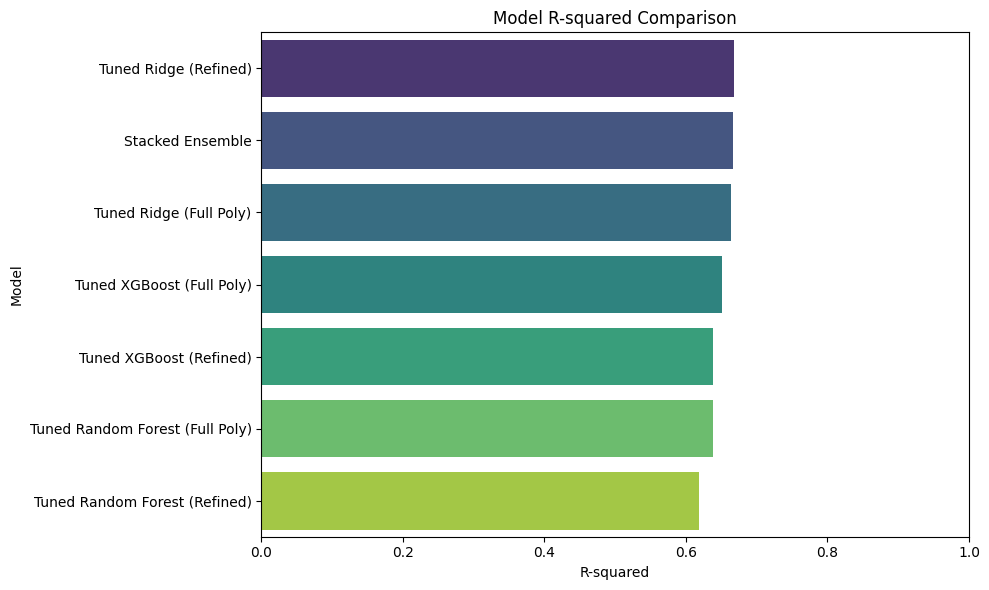

In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(x='R-squared', y='Model', data=results.sort_values(by='R-squared', ascending=False), palette='viridis')
plt.title('Model R-squared Comparison')
plt.xlabel('R-squared')
plt.ylabel('Model')
plt.xlim(0, 1) # R-squared typically ranges from 0 to 1
plt.tight_layout()
plt.show()

## Saving Outputs to Files

In [74]:
# Save the original DataFrame to a CSV file
df.to_csv('housing_data_cleaned.csv', index=False)
print("Saved 'housing_data_cleaned.csv'")

# Save the model performance comparison results to a CSV file
results.to_csv('model_performance_results.csv', index=False)
print("Saved 'model_performance_results.csv'")

# You can save other DataFrames similarly, for example:
# importance_df.to_csv('feature_importances.csv', index=False)
# error_analysis_df.to_csv('error_analysis.csv', index=False)

Saved 'housing_data_cleaned.csv'
Saved 'model_performance_results.csv'


In [75]:
from google.colab import files

files.download('housing_data_cleaned.csv')
files.download('model_performance_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>